# SNID vs Dynesty — Method Comparison Plots
Run cells **1 → 4** in order on first load. After that, any individual plot cell (5 or 6) can be re-run independently after tweaking its parameters.

## 1 · Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.gridspec import GridSpec
from pathlib import Path

## 2 · Configuration
Edit file paths, filter thresholds, and plot style here.

In [2]:
PROJECT_ROOT = Path().resolve().parent  # works when cwd is src/

# ── File paths ────────────────────────────────────────────────────────────────
DYNESTY_FILE = PROJECT_ROOT / 'outputs' / 'csvs'              / 'allcfa_results.csv'
SNID_FILE    = PROJECT_ROOT / 'outputs' / 'method_comparison' / 'cfa_SNID_results.csv'
OUTPUT_DIR   = PROJECT_ROOT / 'outputs' / 'method_comparison'
STYLE_FILE   = PROJECT_ROOT / 'assets'  / 'plotting_style.mplstyle'

# ── Filter thresholds ─────────────────────────────────────────────────────────
PHASE_MIN      = -15     # days  — applied to true_age AND age_fit
PHASE_MAX      =  25     # days
SNR_MIN        =  10     # minimum S/N ratio
SUBTYPES_KEEP  = ['N', 'HV']   # SNID subtypes to include

# ── Apply matplotlib style if available ───────────────────────────────────────
if os.path.exists(STYLE_FILE):
    plt.style.use(STYLE_FILE)
    print(f"Style loaded: {STYLE_FILE}")
else:
    print(f"Style file not found ({STYLE_FILE}), using matplotlib defaults.")

Style loaded: /Users/pxm588@student.bham.ac.uk/PhD/bayesian_framework/assets/plotting_style.mplstyle


## 3 · Load & Merge Data

In [3]:
df_dyn  = pd.read_csv(DYNESTY_FILE)
df_snid = pd.read_csv(SNID_FILE)

# Normalise filenames for a case-insensitive merge
df_dyn ['filename_norm'] = df_dyn ['filename'].str.lower()
df_snid['filename_norm'] = df_snid['Filename'].str.lower()

df_merged = pd.merge(df_dyn, df_snid, on='filename_norm', suffixes=('_dyn', '_snid'))

# ── Resolve column names that may gain a suffix after the merge ───────────────
snr_col      = 'SNR_snid'     if 'SNR_snid'     in df_merged.columns else 'SNR'
subtype_col  = 'Subtype_snid' if 'Subtype_snid' in df_merged.columns else 'Subtype'
true_age_col = 'true_age_dyn' if 'true_age_dyn' in df_merged.columns else 'true_age'

print(f"Merged rows : {len(df_merged)}")
print(f"Columns used — SNR: '{snr_col}'  |  Subtype: '{subtype_col}'  |  True age: '{true_age_col}'")
df_merged.head()

Merged rows : 2603
Columns used — SNR: 'SNR'  |  Subtype: 'Subtype'  |  True age: 'true_age'


,filename,true_age,z_true,logz,logzerr,ncall,eff,chi2,ndof,age_fit,...,Age_Unc_(days),redshift,Dm15,Subtype,dm15,bootstrap_age,snid_std_dev,delta_age,delta_age_unc,MJD
0,sn2007qe-20071229.14-fast.flm,33.440766,0.0239,-1728.744015,0.207435,[1 2 1 ... 1 1 1],5.628202,3448.662239,2659,30.386086,...,0.000000,0.0239,1.03,NaN,1.03,31.650,3.0596,-1.790766,3.059600,54463.14
1,sn2001en-20011018.35-fast.flm,8.313656,0.0164,-29013.412509,0.257218,[1 2 2 ... 1 1 1],4.559535,58011.655672,2545,8.004411,...,1.180638,0.0164,1.12,HV,1.12,7.350,0.2559,-0.963656,1.208052,52200.35
2,sn2002he-20021113.53-fast.flm,5.592426,0.0246,-4949.600717,0.238604,[1 1 4 ... 1 1 1],4.872965,9886.029884,2545,5.289173,...,0.195198,0.0246,1.44,HV,1.44,5.600,0.5310,0.007574,0.565741,52591.53
3,sn2000B-20000210.31-fast.flm,21.499362,0.0191,-14378.044121,0.253187,[1 2 1 ... 1 1 1],4.777791,28741.312698,2532,24.258241,...,1.275635,0.0191,1.46,NaN,1.46,27.500,2.9216,6.000638,3.187945,51584.31
4,sn2001G-20010221.28-fast.flm,31.156570,0.0168,-7285.040276,0.252324,[1 1 1 ... 1 1 1],4.821234,14555.411180,2545,27.168455,...,2.163651,0.0168,NaN,N,NaN,34.875,1.5675,3.718430,2.671786,51961.28


## 4 · Filter & Compute Statistics
Thresholds are pulled from the **Configuration** cell above.

In [ ]:
# Drop rows missing either age estimate
df_clean = df_merged.dropna(subset=['age_fit', 'bootstrap_age']).copy()

mask = (
    df_clean[true_age_col].between(PHASE_MIN, PHASE_MAX) &
    df_clean['age_fit']  .between(PHASE_MIN, PHASE_MAX) &
    (df_clean[snr_col]   >= SNR_MIN) &
    (df_clean['failed']  == False) &
    df_clean[subtype_col].isin(SUBTYPES_KEEP)
)

df_f = df_clean[mask].copy()   # df_f  =  filtered DataFrame used by all plots

if df_f.empty:
    raise RuntimeError("No spectra remain after filtering — check thresholds.")

# ── Statistics ────────────────────────────────────────────────────────────────
residuals   = df_f['bootstrap_age'] - df_f['age_fit']
corr, _     = pearsonr(df_f['age_fit'], df_f['bootstrap_age'])
rmse        = np.sqrt((residuals**2).mean())
bias        = residuals.mean()
std_resid   = residuals.std()

salt_resids = df_f['age_fit'] - df_f['true_age']

print(f"N spectra  : {len(df_f)}")
print(f"Correlation: {corr:.3f}")
print(f"RMSE       : {rmse:.3f} d")
print(f"Bias (SNID − Dynesty): {bias:.3f} d")
print(f"Std resid  : {std_resid:.3f} d")

N spectra  : 955
Correlation: 0.886
RMSE       : 4.520 d
Bias (SNID − Dynesty): -0.098 d
Std resid  : 4.522 d


## 5 · Plot 1 — SNID vs Dynesty (one-to-one + residuals)
Tweak the plotting parameters in the config block at the top of this cell, then re-run.

Saved → /Users/pxm588@student.bham.ac.uk/PhD/bayesian_framework/outputs/method_comparison/snid_vs_dynesty_one_to_one_with_residuals.png


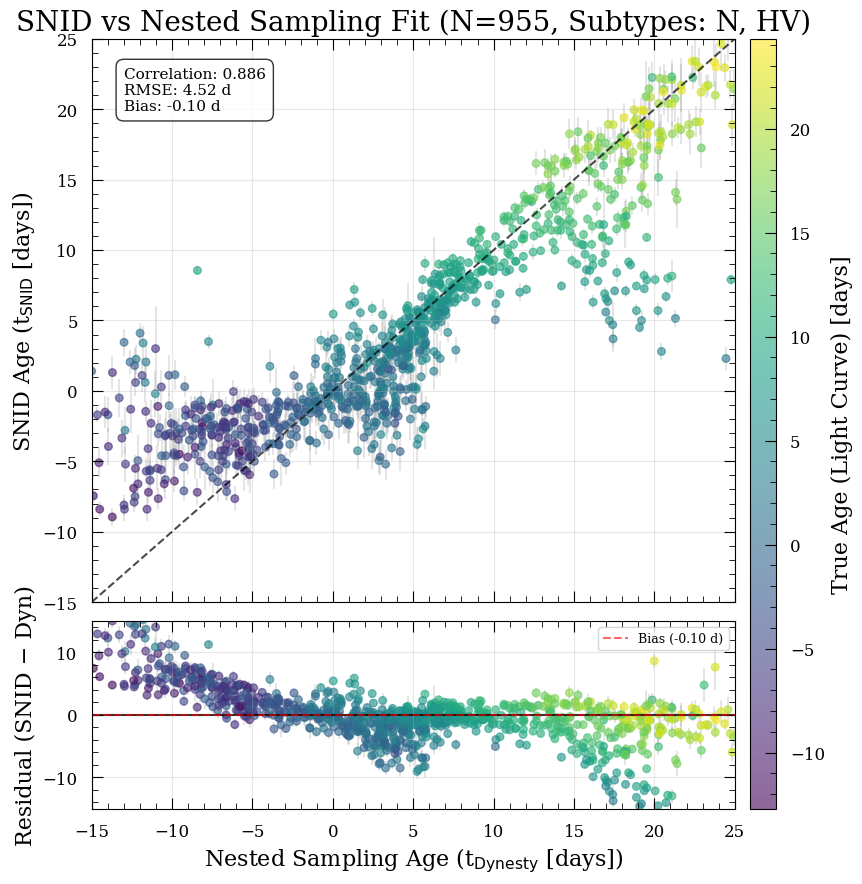

In [5]:
# ── Plot 1 config ─────────────────────────────────────────────────────────────
P1 = dict(
    figsize        = (10, 10),
    height_ratios  = [3, 1],
    hspace         = 0.05,
    xlim           = (PHASE_MIN, PHASE_MAX),
    ylim_main      = (PHASE_MIN, PHASE_MAX),
    ylim_resid     = (-15, 15),
    scatter_cmap   = 'viridis',
    scatter_alpha  = 0.6,
    scatter_size   = 30,
    errorbar_color = 'gray',
    errorbar_alpha = 0.2,
    metrics_fontsize = 11,
    save_path      = os.path.join(OUTPUT_DIR, 'snid_vs_dynesty_one_to_one_with_residuals.png'),
    dpi            = 300,
)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=P1['figsize'])
gs  = GridSpec(2, 1, height_ratios=P1['height_ratios'], hspace=P1['hspace'])

ax_main  = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax_main)

# ── Scatter (coloured by true age) ───────────────────────────────────────────
scatter = ax_main.scatter(
    df_f['age_fit'], df_f['bootstrap_age'],
    c=df_f[true_age_col], cmap=P1['scatter_cmap'],
    alpha=P1['scatter_alpha'], s=P1['scatter_size'], label='Spectra'
)

# ── Error bars (only if both error columns are present) ───────────────────────
has_age_err  = 'age_err'      in df_f.columns
has_snid_err = 'snid_std_dev' in df_f.columns

if has_age_err and has_snid_err:
    ax_main.errorbar(
        df_f['age_fit'], df_f['bootstrap_age'],
        xerr=df_f['age_err'], yerr=df_f['snid_std_dev'],
        fmt='none', color=P1['errorbar_color'], alpha=P1['errorbar_alpha'], zorder=0
    )
    combined_err = np.sqrt(df_f['age_err']**2 + df_f['snid_std_dev']**2)
    ax_resid.errorbar(
        df_f['age_fit'], residuals,
        yerr=combined_err,
        fmt='none', color=P1['errorbar_color'], alpha=P1['errorbar_alpha'], zorder=0
    )

# ── 1:1 line ─────────────────────────────────────────────────────────────────
ax_main.plot(P1['xlim'], P1['xlim'], color='black', linestyle='--', alpha=0.7, label='1:1 Line')

# ── Labels & decorations ──────────────────────────────────────────────────────
ax_main.set_ylabel(r"SNID Age ($t_{\mathrm{SNID}}$ [days])")
ax_main.set_title(fr"SNID vs Nested Sampling Fit (N={len(df_f)}, Subtypes: {', '.join(SUBTYPES_KEEP)})")
ax_main.grid(True, alpha=0.3)
ax_main.set_xlim(*P1['xlim'])
ax_main.set_ylim(*P1['ylim_main'])

metrics_text = (f"Correlation: {corr:.3f}\n"
                f"RMSE: {rmse:.2f} d\n"
                f"Bias: {bias:.2f} d")
ax_main.text(
    0.05, 0.95, metrics_text,
    transform=ax_main.transAxes, va='top', ha='left',
    fontsize=P1['metrics_fontsize'],
    bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='black', alpha=0.8)
)

cbar = fig.colorbar(scatter, ax=[ax_main, ax_resid], pad=0.02, aspect=30)
cbar.set_label('True Age (Light Curve) [days]')

# ── Residual panel ────────────────────────────────────────────────────────────
ax_resid.scatter(
    df_f['age_fit'], residuals,
    c=df_f[true_age_col], cmap=P1['scatter_cmap'],
    alpha=P1['scatter_alpha'], s=P1['scatter_size']
)
ax_resid.axhline(0,    color='black', linestyle='-',  alpha=0.8)
ax_resid.axhline(bias, color='red',   linestyle='--', alpha=0.6, label=f'Bias ({bias:.2f} d)')
ax_resid.set_xlabel(r"Nested Sampling Age ($t_{\mathrm{Dynesty}}$ [days])")
ax_resid.set_ylabel(r"Residual (SNID − Dyn)")
ax_resid.set_ylim(*P1['ylim_resid'])
ax_resid.grid(True, alpha=0.3)
ax_resid.legend(loc='upper right', fontsize=9)

plt.setp(ax_main.get_xticklabels(), visible=False)

os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(P1['save_path'], dpi=P1['dpi'], bbox_inches='tight')
print(f"Saved → {P1['save_path']}")
plt.show()

## 6 · Plot 2 — Found vs True Age (Dynesty & SNID overlaid)
Tweak the plotting parameters in the config block at the top of this cell, then re-run.

Saved → /Users/pxm588@student.bham.ac.uk/PhD/bayesian_framework/outputs/method_comparison/found_vs_true_age_comparison.png


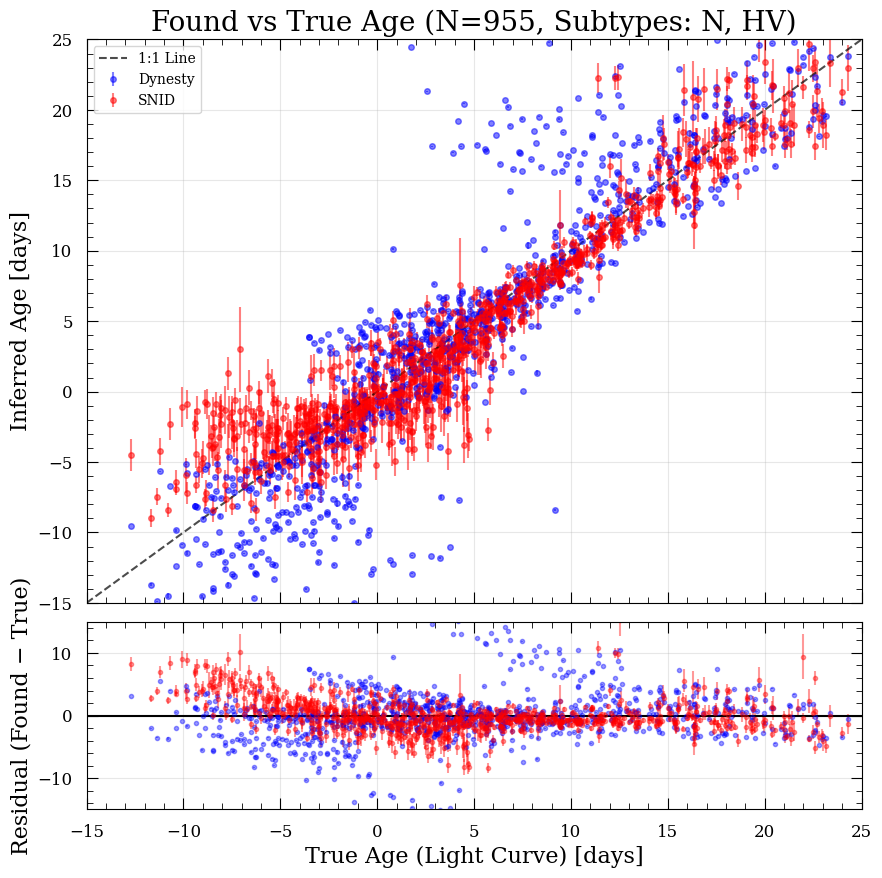

In [6]:
# ── Plot 2 config ─────────────────────────────────────────────────────────────
P2 = dict(
    figsize        = (10, 10),
    height_ratios  = [3, 1],
    hspace         = 0.05,
    xlim           = (PHASE_MIN, PHASE_MAX),
    ylim_main      = (PHASE_MIN, PHASE_MAX),
    ylim_resid     = (-15, 15),
    color_dynesty  = 'blue',
    color_snid     = 'red',
    marker_alpha   = 0.5,
    markersize     = 4,
    resid_alpha    = 0.4,
    resid_size     = 3,
    save_path      = os.path.join(OUTPUT_DIR, 'found_vs_true_age_comparison.png'),
    dpi            = 300,
)
# ─────────────────────────────────────────────────────────────────────────────

true_age = df_f[true_age_col]
has_age_err  = 'age_err'      in df_f.columns
has_snid_err = 'snid_std_dev' in df_f.columns

fig2 = plt.figure(figsize=P2['figsize'])
gs2  = GridSpec(2, 1, height_ratios=P2['height_ratios'], hspace=P2['hspace'])

ax2_main  = fig2.add_subplot(gs2[0])
ax2_resid = fig2.add_subplot(gs2[1], sharex=ax2_main)

# ── Main panel ────────────────────────────────────────────────────────────────
ax2_main.errorbar(
    true_age, df_f['age_fit'],
    yerr=df_f['age_err'] if has_age_err else None,
    label='Dynesty', color=P2['color_dynesty'],
    fmt='o', alpha=P2['marker_alpha'], markersize=P2['markersize'], capsize=0
)
ax2_main.errorbar(
    true_age, df_f['bootstrap_age'],
    yerr=df_f['snid_std_dev'] if has_snid_err else None,
    label='SNID', color=P2['color_snid'],
    fmt='o', alpha=P2['marker_alpha'], markersize=P2['markersize'], capsize=0
)
ax2_main.plot(P2['xlim'], P2['xlim'], 'k--', alpha=0.7, label='1:1 Line')

ax2_main.set_ylabel("Inferred Age [days]")
ax2_main.set_title(fr"Found vs True Age (N={len(df_f)}, Subtypes: {', '.join(SUBTYPES_KEEP)})")
ax2_main.set_xlim(*P2['xlim'])
ax2_main.set_ylim(*P2['ylim_main'])
ax2_main.legend()
ax2_main.grid(True, alpha=0.3)

# ── Residual panel ────────────────────────────────────────────────────────────
res_dyn  = df_f['age_fit']      - true_age
res_snid = df_f['bootstrap_age'] - true_age

ax2_resid.errorbar(
    true_age, res_dyn,
    yerr=df_f['age_err'] if has_age_err else None,
    color=P2['color_dynesty'], fmt='o',
    alpha=P2['resid_alpha'], markersize=P2['resid_size'], capsize=0
)
ax2_resid.errorbar(
    true_age, res_snid,
    yerr=df_f['snid_std_dev'] if has_snid_err else None,
    color=P2['color_snid'], fmt='o',
    alpha=P2['resid_alpha'], markersize=P2['resid_size'], capsize=0
)
ax2_resid.axhline(0, color='black', linestyle='-')
ax2_resid.set_xlabel("True Age (Light Curve) [days]")
ax2_resid.set_ylabel("Residual (Found − True)")
ax2_resid.set_ylim(*P2['ylim_resid'])
ax2_resid.grid(True, alpha=0.3)

plt.setp(ax2_main.get_xticklabels(), visible=False)

os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(P2['save_path'], dpi=P2['dpi'], bbox_inches='tight')
print(f"Saved → {P2['save_path']}")
plt.show()

### Plot 3
SALT3 method plot


In [7]:
# ── Plot 3 config ─────────────────────────────────────────────────────────────
P3 = dict(
    figsize        = (10, 10),
    height_ratios  = [3, 1],
    hspace         = 0.05,
    xlim           = (PHASE_MIN, PHASE_MAX),
    ylim_main      = (PHASE_MIN, PHASE_MAX),
    ylim_resid     = (-15, 15),
    color_dynesty  = 'blue',
    color_snid     = 'red',
    marker_alpha   = 0.5,
    markersize     = 4,
    resid_alpha    = 0.4,
    resid_size     = 3,
    save_path      = os.path.join(OUTPUT_DIR, 'found_vs_true_age_comparison.png'),
    dpi            = 300,
)

# ── Plot 1 config ─────────────────────────────────────────────────────────────
P1 = dict(
    figsize        = (10, 10),
    height_ratios  = [3, 1],
    hspace         = 0.05,
    xlim           = (PHASE_MIN, PHASE_MAX),
    ylim_main      = (PHASE_MIN, PHASE_MAX),
    ylim_resid     = (-15, 15),
    scatter_cmap   = 'viridis',
    scatter_alpha  = 0.6,
    scatter_size   = 30,
    errorbar_color = 'gray',
    errorbar_alpha = 0.2,
    metrics_fontsize = 11,
    save_path      = os.path.join(OUTPUT_DIR, 'snid_vs_dynesty_one_to_one_with_residuals.png'),
    dpi            = 300,
)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=P1['figsize'])
gs  = GridSpec(2, 1, height_ratios=P1['height_ratios'], hspace=P1['hspace'])

ax_main  = fig.add_subplot(gs[0])
ax_resid = fig.add_subplot(gs[1], sharex=ax_main)

# ── Scatter (coloured by true age) ───────────────────────────────────────────
scatter = ax_main.scatter(
    df_f['age_fit'], df_f['bootstrap_age'],
    c=df_f[true_age_col], cmap=P1['scatter_cmap'],
    alpha=P1['scatter_alpha'], s=P1['scatter_size'], label='Spectra'
)

# ── Error bars (only if both error columns are present) ───────────────────────
has_age_err  = 'age_err'      in df_f.columns
has_snid_err = 'snid_std_dev' in df_f.columns

if has_age_err and has_snid_err:
    ax_main.errorbar(
        df_f['age_fit'], df_f['bootstrap_age'],
        xerr=df_f['age_err'], yerr=df_f['snid_std_dev'],
        fmt='none', color=P1['errorbar_color'], alpha=P1['errorbar_alpha'], zorder=0
    )
    combined_err = np.sqrt(df_f['age_err']**2 + df_f['snid_std_dev']**2)
    ax_resid.errorbar(
        df_f['age_fit'], residuals,
        yerr=combined_err,
        fmt='none', color=P1['errorbar_color'], alpha=P1['errorbar_alpha'], zorder=0
    )

# ── 1:1 line ─────────────────────────────────────────────────────────────────
ax_main.plot(P1['xlim'], P1['xlim'], color='black', linestyle='--', alpha=0.7, label='1:1 Line')

# ── Labels & decorations ──────────────────────────────────────────────────────
ax_main.set_ylabel(r"SNID Age ($t_{\mathrm{SNID}}$ [days])")
ax_main.set_title(fr"SNID vs Nested Sampling Fit (N={len(df_f)}, Subtypes: {', '.join(SUBTYPES_KEEP)})")
ax_main.grid(True, alpha=0.3)
ax_main.set_xlim(*P1['xlim'])
ax_main.set_ylim(*P1['ylim_main'])

metrics_text = (f"Correlation: {corr:.3f}\n"
                f"RMSE: {rmse:.2f} d\n"
                f"Bias: {bias:.2f} d")
ax_main.text(
    0.05, 0.95, metrics_text,
    transform=ax_main.transAxes, va='top', ha='left',
    fontsize=P1['metrics_fontsize'],
    bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='black', alpha=0.8)
)

cbar = fig.colorbar(scatter, ax=[ax_main, ax_resid], pad=0.02, aspect=30)
cbar.set_label('True Age (Light Curve) [days]')

# ── Residual panel ────────────────────────────────────────────────────────────
ax_resid.scatter(
    df_f['age_fit'], residuals,
    c=df_f[true_age_col], cmap=P1['scatter_cmap'],
    alpha=P1['scatter_alpha'], s=P1['scatter_size']
)
ax_resid.axhline(0,    color='black', linestyle='-',  alpha=0.8)
ax_resid.axhline(bias, color='red',   linestyle='--', alpha=0.6, label=f'Bias ({bias:.2f} d)')
ax_resid.set_xlabel(r"Nested Sampling Age ($t_{\mathrm{Dynesty}}$ [days])")
ax_resid.set_ylabel(r"Residual (SNID − Dyn)")
ax_resid.set_ylim(*P1['ylim_resid'])
ax_resid.grid(True, alpha=0.3)
ax_resid.legend(loc='upper right', fontsize=9)

plt.setp(ax_main.get_xticklabels(), visible=False)

os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(P1['save_path'], dpi=P1['dpi'], bbox_inches='tight')
print(f"Saved → {P1['save_path']}")
plt.show()